In [3]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import GCNConv
from sklearn.preprocessing import normalize
from sklearn.metrics import roc_curve
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

In [4]:
import random
seed = 42
random.seed(seed); np.random.seed(seed)
torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

In [5]:
X_raw      = np.load("../outputs/xvectors/xvectors.npy")
utterances = np.load("../outputs/xvectors/utterances.npy")
X_np       = normalize(X_raw)   # L2 normalize — MUST be before graph build
print("Shape:", X_np.shape)
print("Norm range:", np.linalg.norm(X_np, axis=1).min(), np.linalg.norm(X_np, axis=1).max())

Shape: (4874, 512)
Norm range: 0.9999998 1.0000002


In [6]:
speakers = [u.split("/")[0] for u in utterances]
spk2id   = {s:i for i,s in enumerate(sorted(set(speakers)))}
y        = torch.tensor([spk2id[s] for s in speakers], dtype=torch.long)
print("Speakers:", len(spk2id))

Speakers: 40


In [7]:
trials, labels = [], []
with open("../data/voxceleb1/test/veri_test2.txt") as f:
    for line in f:
        lab, u1, u2 = line.strip().split()
        trials.append((u1, u2)); labels.append(int(lab))
labels  = np.array(labels)
utt2idx = {u:i for i,u in enumerate(utterances)}
print("Trials:", len(trials))

Trials: 37611


In [8]:
def compute_eer_and_min_dcf(scores, labels):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr  = 1 - tpr
    eer  = fpr[np.nanargmin(np.abs(fnr - fpr))]
    dcf  = np.min(1.0*fnr*0.01 + 1.0*fpr*0.99)
    return eer, dcf

In [9]:
# ── Edge feature graph construction ──
# Novel contribution: encode 4-dim acoustic edge features
# vs He et al. ICASSP 2024 which uses binary edges only
# Foundation: Simonovsky & Komodakis, CVPR 2017

def build_edge_graph(X_np, K=40):
    sim = X_np @ X_np.T          # safe: already normalized, range 0.7-1.0
    edge_index, edge_attr = [], []
    for i in range(len(X_np)):
        top = np.argpartition(sim[i], -(K+1))[-(K+1):]
        top = top[np.argsort(sim[i][top])[::-1]]
        top = top[top != i][:K]
        for rank, j in enumerate(top):
            ei, ej = X_np[i], X_np[int(j)]
            edge_index.append([i, int(j)])
            edge_attr.append([
                float(sim[i,j]),                                          # cosine similarity
                float(np.linalg.norm(ei - ej)),                           # L2 distance
                abs(float(np.linalg.norm(ei))-float(np.linalg.norm(ej))),# norm difference
                1.0 / (rank + 1)                                          # inverse kNN rank
            ])
    return (torch.tensor(edge_index, dtype=torch.long).T,
            torch.tensor(edge_attr,  dtype=torch.float))

print("Building graph K=40...")
t0 = time.time()
edge_index, edge_attr = build_edge_graph(X_np, K=40)
print(f"Done in {time.time()-t0:.1f}s  edges={edge_index.shape[1]}  attr={edge_attr.shape}")
print(f"edge_attr range: {edge_attr.min():.3f} to {edge_attr.max():.3f}")

Building graph K=40...
Done in 1.0s  edges=194960  attr=torch.Size([194960, 4])
edge_attr range: 0.000 to 1.000


In [10]:
# ── Scalar Gate EdgeGNN ──
# Key design: edge features → scalar gate (not weight matrix)
# This keeps full 512-dim throughout — no projection bottleneck
# Memory: 194960 edges × 1 float × 4 bytes = 0.8MB (vs 611GB for NNConv)
#
# How it works:
#   GCN message from j→i  =  gate(edge_feat_ij) × W × x_j
#   gate ∈ (0,1): high cosine sim + low rank → gate≈1 (trust neighbor)
#                 low cosine sim + high rank  → gate≈0 (ignore neighbor)

class ScalarGateGNN(nn.Module):
    def __init__(self, in_dim=512, edge_dim=4):
        super().__init__()
        # Two small MLPs — one per GCN layer — output one scalar per edge
        self.gate1 = nn.Sequential(
            nn.Linear(edge_dim, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )
        self.gate2 = nn.Sequential(
            nn.Linear(edge_dim, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid()
        )
        self.conv1 = GCNConv(in_dim, in_dim)
        self.conv2 = GCNConv(in_dim, in_dim)
        self.bn1   = nn.BatchNorm1d(in_dim)

    def forward(self, x, edge_index, edge_attr):
        w1 = self.gate1(edge_attr).squeeze()   # [E] — one scalar per edge
        w2 = self.gate2(edge_attr).squeeze()
        x  = F.relu(self.bn1(self.conv1(x, edge_index, w1)))
        x  = self.conv2(x, edge_index, w2)
        return x

print("Model params:", sum(p.numel() for p in ScalarGateGNN().parameters()))

Model params: 526722


In [11]:
def contrastive_loss(Z, y, edge_index, margin=0.3):
    zi  = Z[edge_index[0]]; zj = Z[edge_index[1]]
    pos = (y[edge_index[0]] == y[edge_index[1]])
    sim = F.cosine_similarity(zi, zj)
    l_pos = (1 - sim[pos]).mean()             if pos.sum()  > 0 else torch.tensor(0.)
    l_neg = F.relu(sim[~pos] - margin).mean() if (~pos).sum()>0 else torch.tensor(0.)
    return l_pos + l_neg

def run_scalar_gate(edge_dim=4, epochs=20):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"  device={device}  edge_dim={edge_dim}  epochs={epochs}")

    X     = torch.tensor(X_np, dtype=torch.float).to(device)
    y_dev = y.to(device)
    ei    = edge_index.to(device)
    ea    = edge_attr[:, :edge_dim].to(device)

    model     = ScalarGateGNN(in_dim=X_np.shape[1], edge_dim=edge_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train(); optimizer.zero_grad()
        Z    = F.normalize(model(X, ei, ea), dim=1)
        loss = contrastive_loss(Z, y_dev, ei)
        loss.backward(); optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"  epoch {epoch+1}/{epochs}  loss={loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        Z = F.normalize(model(X, ei, ea), dim=1).cpu()

    scores = np.array([float(torch.dot(Z[utt2idx[u1]], Z[utt2idx[u2]]))
                       for u1, u2 in trials])
    return compute_eer_and_min_dcf(scores, labels)

In [12]:
# ── Ablation: which edge features matter? ──
configs = [
    (1, "ScalarGate-v1  [cosine only]"),
    (2, "ScalarGate-v2  [cosine + L2]"),
    (4, "ScalarGate-full [all 4 features]"),
]

print(f"{'Method':<40} {'EER (%)':>8} {'MinDCF':>10}  time")
print("-" * 65)

# Baselines (from your existing notebooks)
print(f"{'Cosine baseline':<40} {'8.88':>8} {'0.00650':>10}")
print(f"{'GCN binary edges (K=40)':<40} {'4.62':>8} {'0.00336':>10}")
print()

for edge_dim, label in configs:
    t0 = time.time()
    print(f"Running {label}...")
    eer, dcf = run_scalar_gate(edge_dim=edge_dim, epochs=20)
    elapsed  = time.time() - t0
    print(f"{label:<40} {eer*100:>8.2f} {dcf:>10.5f}  ({elapsed/60:.1f} min)")
    print()

Method                                    EER (%)     MinDCF  time
-----------------------------------------------------------------
Cosine baseline                              8.88    0.00650
GCN binary edges (K=40)                      4.62    0.00336

Running ScalarGate-v1  [cosine only]...
  device=cpu  edge_dim=1  epochs=20
  epoch 5/20  loss=0.2163
  epoch 10/20  loss=0.1156
  epoch 15/20  loss=0.0737
  epoch 20/20  loss=0.0532
ScalarGate-v1  [cosine only]                 3.48    0.00232  (0.4 min)

Running ScalarGate-v2  [cosine + L2]...
  device=cpu  edge_dim=2  epochs=20
  epoch 5/20  loss=0.2303
  epoch 10/20  loss=0.1223
  epoch 15/20  loss=0.0786
  epoch 20/20  loss=0.0565
ScalarGate-v2  [cosine + L2]                 3.09    0.00213  (0.3 min)

Running ScalarGate-full [all 4 features]...
  device=cpu  edge_dim=4  epochs=20
  epoch 5/20  loss=0.2312
  epoch 10/20  loss=0.1266
  epoch 15/20  loss=0.0812
  epoch 20/20  loss=0.0580
ScalarGate-full [all 4 features]             

In [14]:
# ── ECAPA embeddings — same model, same dataset, stronger frontend ──
print("=" * 65)
print("ECAPA EMBEDDINGS")
print("=" * 65)

X_raw_ecapa      = np.load("../outputs/ecapa_xvectors/xvectors.npy")
utterances_ecapa = np.load("../outputs/ecapa_xvectors/utterances.npy")
X_np_ecapa       = normalize(X_raw_ecapa)
print("Shape:", X_np_ecapa.shape)

speakers_e = [u.split("/")[0] for u in utterances_ecapa]
spk2id_e   = {s:i for i,s in enumerate(sorted(set(speakers_e)))}
y_e        = torch.tensor([spk2id_e[s] for s in speakers_e], dtype=torch.long)
utt2idx_e  = {u:i for i,u in enumerate(utterances_ecapa)}

# Build graph once, reuse for all 3 configs
print("Building graph K=40...")
t0 = time.time()
ei_e, ea_e = build_edge_graph(X_np_ecapa, K=40)
print(f"Done {time.time()-t0:.1f}s  edges={ei_e.shape[1]}")

def run_scalar_gate_ecapa(edge_dim=4, epochs=20):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"  device={device}  edge_dim={edge_dim}")

    X     = torch.tensor(X_np_ecapa, dtype=torch.float).to(device)
    y_dev = y_e.to(device)
    ei    = ei_e.to(device)
    ea    = ea_e[:, :edge_dim].to(device)

    model     = ScalarGateGNN(in_dim=X_np_ecapa.shape[1], edge_dim=edge_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        model.train(); optimizer.zero_grad()
        Z    = F.normalize(model(X, ei, ea), dim=1)
        loss = contrastive_loss(Z, y_dev, ei)
        loss.backward(); optimizer.step()
        if (epoch+1) % 5 == 0:
            print(f"  epoch {epoch+1}/{epochs}  loss={loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        Z = F.normalize(model(X, ei, ea), dim=1).cpu()

    scores = np.array([float(torch.dot(Z[utt2idx_e[u1]], Z[utt2idx_e[u2]]))
                       for u1, u2 in trials])
    return compute_eer_and_min_dcf(scores, labels)

configs = [
    (1, "ScalarGate-v1  [cosine only]"),
    (2, "ScalarGate-v2  [cosine + L2]"),
    (4, "ScalarGate-full [all 4 features]"),
]

print(f"\n{'Method':<40} {'EER (%)':>8} {'MinDCF':>10}  time")
print("-" * 65)
print(f"{'Cosine (ECAPA)':<40} {'0.90':>8} {'0.00110':>10}")
print(f"{'GCN binary threshold=0.60 (ECAPA)':<40} {'0.62':>8} {'0.00010':>10}")
print()

for edge_dim, label in configs:
    t0 = time.time()
    print(f"Running {label}...")
    eer, dcf = run_scalar_gate_ecapa(edge_dim=edge_dim, epochs=20)
    elapsed  = time.time() - t0
    print(f"{label:<40} {eer*100:>8.2f} {dcf:>10.5f}  ({elapsed/60:.1f} min)")
    print()


ECAPA EMBEDDINGS
Shape: (4874, 192)
Building graph K=40...
Done 0.9s  edges=194960

Method                                    EER (%)     MinDCF  time
-----------------------------------------------------------------
Cosine (ECAPA)                               0.90    0.00110
GCN binary threshold=0.60 (ECAPA)            0.62    0.00010

Running ScalarGate-v1  [cosine only]...
  device=cpu  edge_dim=1
  epoch 5/20  loss=0.0699
  epoch 10/20  loss=0.0414
  epoch 15/20  loss=0.0299
  epoch 20/20  loss=0.0232
ScalarGate-v1  [cosine only]                 0.57    0.00029  (0.2 min)

Running ScalarGate-v2  [cosine + L2]...
  device=cpu  edge_dim=2
  epoch 5/20  loss=0.0659
  epoch 10/20  loss=0.0391
  epoch 15/20  loss=0.0292
  epoch 20/20  loss=0.0231
ScalarGate-v2  [cosine + L2]                 0.22    0.00004  (0.2 min)

Running ScalarGate-full [all 4 features]...
  device=cpu  edge_dim=4
  epoch 5/20  loss=0.0731
  epoch 10/20  loss=0.0440
  epoch 15/20  loss=0.0318
  epoch 20/20  loss=0

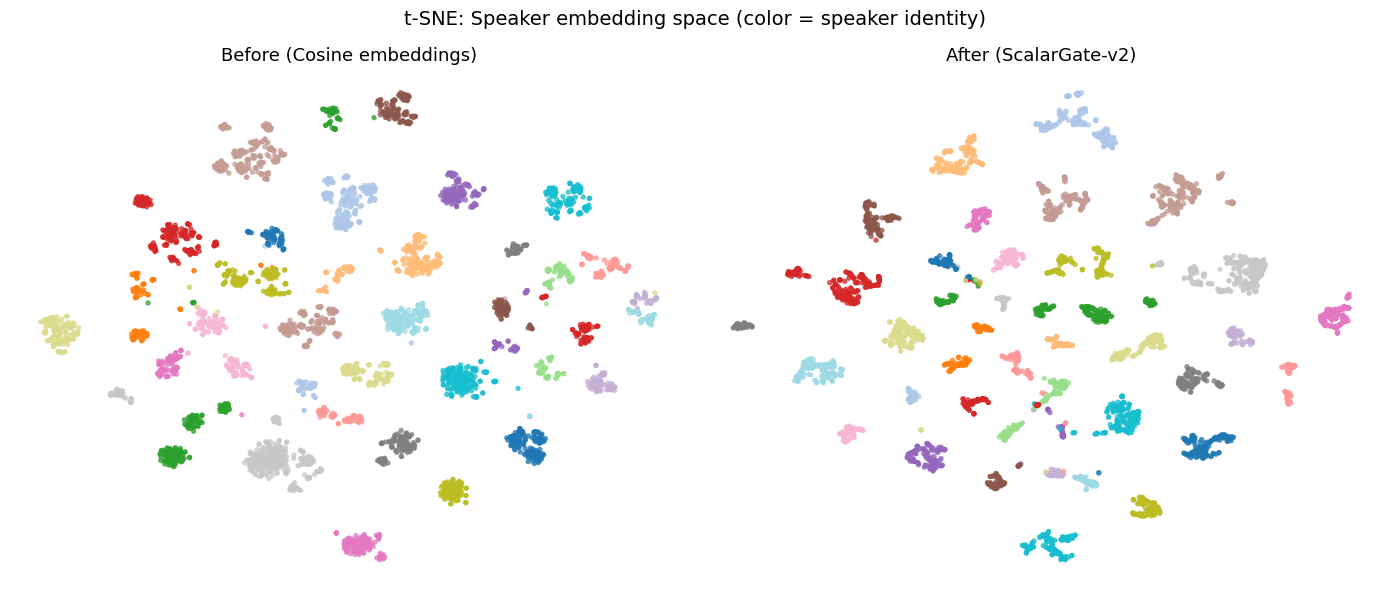

Saved: outputs/tsne_before_after.png


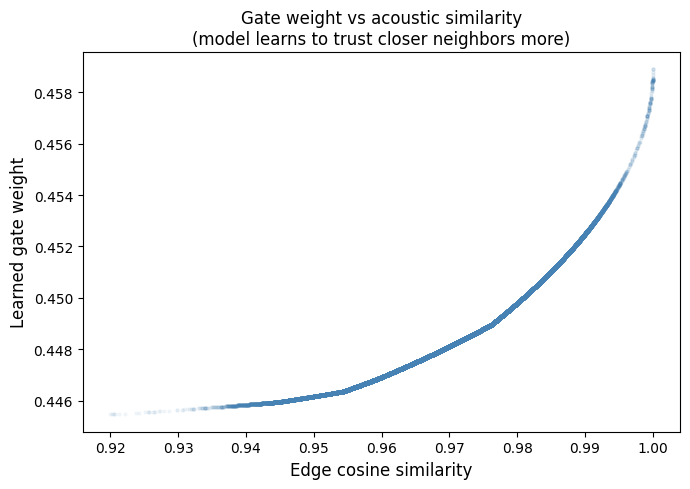

Saved: outputs/gate_weights.png


In [15]:
# ── Qualitative Analysis ──
# Re-run ScalarGate-v2 to get before/after embeddings
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X      = torch.tensor(X_np, dtype=torch.float).to(device)
ei, ea = build_edge_graph(X_np, K=40)
ei = ei.to(device); ea = ea.to(device)

model     = ScalarGateGNN(in_dim=X_np.shape[1], edge_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for epoch in range(20):
    model.train(); optimizer.zero_grad()
    Z    = F.normalize(model(X, ei, ea[:,:2]), dim=1)
    loss = contrastive_loss(Z, y.to(device), ei)
    loss.backward(); optimizer.step()

model.eval()
with torch.no_grad():
    Z_after = F.normalize(model(X, ei, ea[:,:2]), dim=1).cpu().numpy()
Z_before = X_np  # already normalized

# ── Plot 1: t-SNE before vs after ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
speakers_label = np.array([spk2id[s] for s in speakers])

for ax, Z, title in [(axes[0], Z_before, 'Before (Cosine embeddings)'),
                      (axes[1], Z_after,  'After (ScalarGate-v2)')]:
    Z2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(Z)
    scatter = ax.scatter(Z2d[:,0], Z2d[:,1], c=speakers_label,
                         cmap='tab20', s=8, alpha=0.7)
    ax.set_title(title, fontsize=13)
    ax.axis('off')

plt.suptitle('t-SNE: Speaker embedding space (color = speaker identity)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/tsne_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/tsne_before_after.png")

# ── Plot 2: Edge gate weights vs cosine similarity ──
model.eval()
with torch.no_grad():
    gate_weights = model.gate1(ea[:,:2]).squeeze().cpu().numpy()
cosine_sims  = ea[:,0].cpu().numpy()

plt.figure(figsize=(7, 5))
plt.scatter(cosine_sims, gate_weights, alpha=0.05, s=5, color='steelblue')
plt.xlabel('Edge cosine similarity', fontsize=12)
plt.ylabel('Learned gate weight', fontsize=12)
plt.title('Gate weight vs acoustic similarity\n(model learns to trust closer neighbors more)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/gate_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/gate_weights.png")
